# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_:
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Gonzales, Naeumi
- _Student No._: 2024-11022
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 (Horner's Rule)

![Absolute deviation and execution times for both functions](time_execution_deviation.png)

Figure 1. Horner's rule and naive polynomial evaluation are compared in terms of execution time and numerical error deviation for polynomial degrees $n \in [1, 500]$.

The execution time as a function of the number of coefficients ($n$) is shown in the graph on the left. Due to redundant exponentiation loops, the naive evaluation (red) shows quadratic growth ($\mathcal{O}(n^2)$), with the average execution time increasing dramatically toward 0.002 seconds at $n = 500$. Horner's rule (blue), on the other hand, confirms its linear time complexity ($\mathcal{O}(n)$) and superior operational efficiency by maintaining a nearly flat, near-zero execution time across all degrees.

### Problem 2 (Horner's Rule for Taylor Series)

![Execution times and Absolute deviation of both function ](sine_func.png)

Figure 2. Comparison of Taylor series evaluation via Horner's rule against NumPy reference implementations for $e^x$ and $\sin(x)$ over $x \in [0, 10]$.

Library-free Taylor series approximations are plotted against NumPy reference functions (np.exp and np.sin). By rewriting the Taylor polynomial into nested linear operations for $e^x$, Horner's rule removes unnecessary power loops.

Exponentiation cannot be totally avoided for $\sin(x)$ since higher-order polynomial terms depend on powers of $x$ by nature. The series can be expressed as $\sin(x) = x \cdot P(x^2)$ by factoring out $x$, which minimizes exponent operations. Horner's method can evaluate $P(y)$ sequentially by computing $y = x^2$ only once, completely omitting even-degree terms and avoiding explicit power calls (x**n).

The Taylor series curves (blue) cover the outputs of NumPy (red) across $x \in [0, 10]$ with no observable deviation. This proves that Horner's rule results in numerical accuracy and stability, consistent with math libraries.

### Other comments
-None


---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.


In [2]:
def eval_naively(coeffs, x):
    #Utilizing explicit repeated multiplication for the naive evaluation of P(x)
    result = 0.0
    for i, coeff in enumerate(coeffs):
        power = 1.0
        for _ in range(i):
            power *= x
        result += coeff * power
    return result


def eval_horner(coeffs, x):
    #Utilizing Horner's rule for the evaluation of P(x) from right to left
    result = 0.0

    for coeff in reversed(coeffs):
        result = result * x + coeff  # Single multiply-add step per term

    return result

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree).

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [5]:
#As given in the problem:
coeffs = [(-11)**i for i in reversed(range(8))]
x = 11.01

naive_val = eval_naively(coeffs, x)
horner_val = eval_horner(coeffs, x)

print(f"Naive evaluation:    {naive_val}")
print(f"Horner's evaluation: {horner_val}")

abs_error = abs(naive_val - horner_val)
print(f"Absolute difference: {abs_error}")

Naive evaluation:    71056.02362163737
Horner's evaluation: 71056.02362163365
Absolute difference: 3.725290298461914e-09


Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

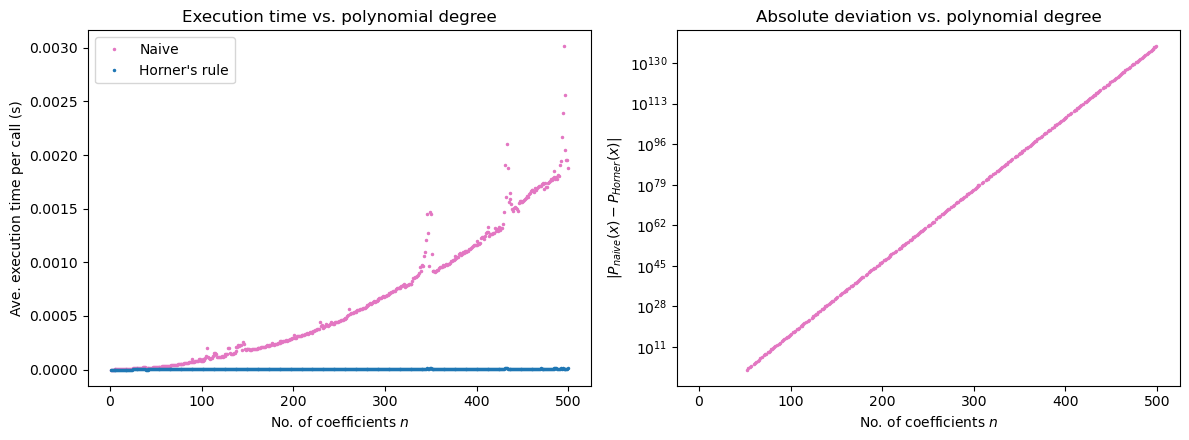

In [6]:
import time
import matplotlib.pyplot as plt

x_eval = 2.0
degrees = range(1, 501)
naive_times = []
horner_times = []
deviations = []
n_repeats = 50  #To obtain a stable timing measurement, this will repeat each execution

for n in degrees:
    #To illustrate floating-point errors, increasing coefficient values are used
    poly_coeffs = [float(k + 1) for k in range(n)]

    #Time evaluation (naively)
    start = time.perf_counter()
    for _ in range(n_repeats):
        naive_val = eval_naively(poly_coeffs, x_eval)
    naive_times.append((time.perf_counter() - start) / n_repeats) # ave. time per call

    #Time evaluation (using Horner's rule)
    start = time.perf_counter()
    for _ in range(n_repeats):
        horner_val = eval_horner(poly_coeffs, x_eval)
    horner_times.append((time.perf_counter() - start) / n_repeats) # ave. time per call

    #Deviations between methods at degree n
    deviations.append(abs(naive_val - horner_val))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

#Utilizing marker='.' and customizing markersize to plot each as individual dots
ax1.plot(degrees, naive_times, '.', label="Naive", color='tab:pink', markersize=3)
ax1.plot(degrees, horner_times, '.', label="Horner's rule", color='tab:blue', markersize=3)
ax1.set_xlabel("No. of coefficients $n$")
ax1.set_ylabel("Ave. execution time per call (s)")
ax1.set_title("Execution time vs. polynomial degree")
ax1.legend()

ax2.plot(degrees, deviations, '.', color='tab:pink', markersize=3)
ax2.set_xlabel("No. of coefficients $n$")
ax2.set_ylabel(r"$|P_{naive}(x) - P_{Horner}(x)|$")
ax2.set_title("Absolute deviation vs. polynomial degree")
ax2.set_yscale("log")
plt.tight_layout()
plt.savefig('time_execution_deviation.png')
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* Comparisons between the two methods to solve polynomial problems are done in the code to illustrate which is more efficient and accurate as problems increasingly grow. Repeated recalculation of exponents is done in the naive method, while Horner's rule recycles former calculations through rewriting the equation into nested steps. The latter method ensures faster processing time and prevention of rounding errors by reducing the total number of mathematical operations.

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

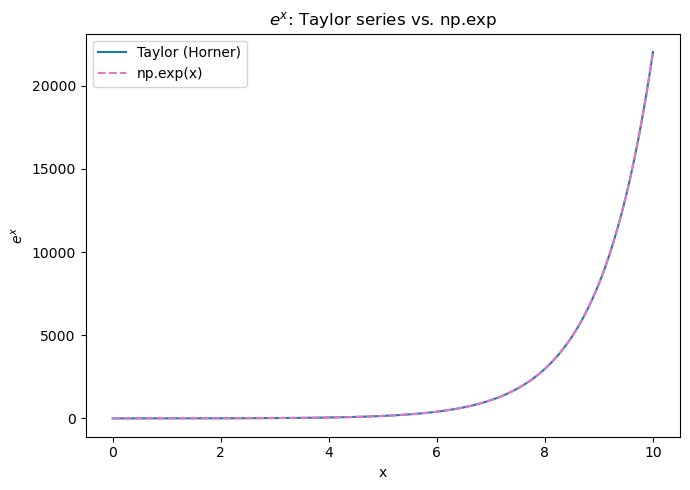

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def eval_horner(coeffs, x):
    #Utilizing Horner's rule for the evaluation of polynomial P(x) starting from the highest degree to the lowest.
    val = 0.0
    for coeff in reversed(coeffs):
        val = val * x + coeff #Multiplying the current value by x, then adding the next coefficient
    return val


def factorial(n):
    # Calculates n! iteratively without external libraries
    result = 1
    for k in range(2, n + 1):
        result *= k
    return result


def taylor_exp_coeffs(n_terms):
    #Returns the first n Taylor coefficients of e^x.
    return [1 / factorial(i) for i in range(n_terms)]


def exp_horner(x, coeffs):
    #Utilizing Horner's rule for the Taylor approximation
    return eval_horner(coeffs, x)


n_terms = 50
coeffs = taylor_exp_coeffs(n_terms)
x_values = np.linspace(0, 10, 400)

#Utilizes Taylor series and Horner's rule for evaluating e^x
exp_taylor = [exp_horner(x, coeffs) for x in x_values]
#Utilizes Numpy to compute e^x
exp_numpy = np.exp(x_values)

plt.figure(figsize=(7, 5))
plt.plot(x_values, exp_taylor, label="Taylor (Horner)", color="tab:blue")
plt.plot(x_values, exp_numpy, "--", label="np.exp(x)", color="tab:pink")

plt.title(r"$e^x$: Taylor series vs. np.exp")
plt.xlabel("x")
plt.ylabel("$e^x$")
plt.legend()
plt.savefig('expfunc.png')
plt.tight_layout()
plt.show()

Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

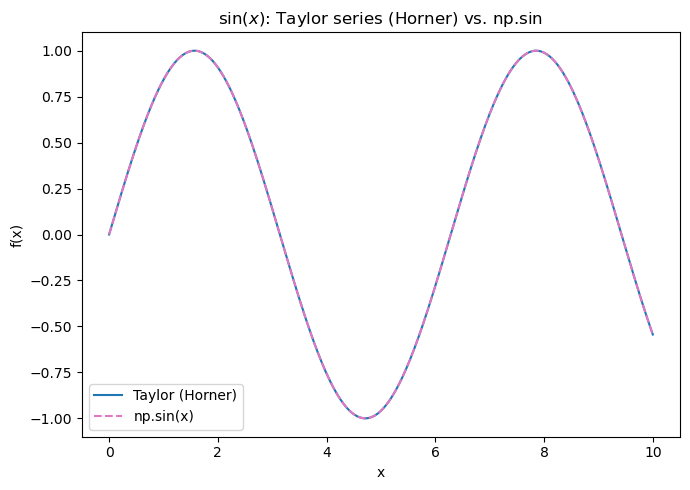

In [8]:

def taylor_sine_coeffs(n_terms):
    #Creates coefficients for sin(x) = x * g(x^2), and avoids using any
    #libraries by calculating sign and factorial gradually in
    #g(y) = sum_k ((-1)^k / (2k+1)!) y^k
    coeffs = []
    sign = 1
    fact = 1

    for k in range(n_terms):
        coeffs.append(sign / fact)
        sign *= -1
        fact *= (2 * k + 2) * (2 * k + 3) #Updates (2k+1)! to (2k+3)! for next term
    return coeffs


def sin_horner(x, n_terms=30):
    #Calculates sin(x) using Horner's rule on odd-power terms using y = x^2 substitution
    coeffs = taylor_sine_coeffs(n_terms)
    y = x * x  #Calculates x^2 once to remove explicit power calculations
    return x * eval_horner(coeffs, y)  #Factor back the removed x term


x_values = np.linspace(0, 10, 400)
sin_taylor = [sin_horner(x) for x in x_values]
sin_numpy = np.sin(x_values)


plt.figure(figsize=(7, 5))
plt.plot(x_values, sin_taylor, label="Taylor (Horner)", color="tab:blue")
plt.plot(x_values, sin_numpy, "--", label="np.sin(x)", color="tab:pink")

plt.title(r"$\sin(x)$: Taylor series (Horner) vs. np.sin")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.savefig('sine_func.png')
plt.tight_layout()
plt.show()

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

* Comparison between Taylor series approximations and Numpy's built-in functions is done in this code by evaluating $e^x$ and $\sin(x)$ across $x \in [0, 10]$. The code utilized Horner's rule for simple operations instead of repeating exponent calculations, while the removal of lost even terms and minimization of multiplication were done by sustituting $y = x^2$ for $\sin(x)$. The plots show the perfect overlay of the custom Taylor series implemented against exp()` and `np.sin()`, indicating the accuracy and stability of Horner's rule.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html).

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [ ]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [ ]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [ ]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [ ]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [ ]:
# you can write truthiness conditionals more succinctly as
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [ ]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [ ]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [ ]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [ ]:
# Tuples are primarily used to bundle related pieces of data together,
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [ ]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [ ]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y)

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [ ]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties
# but keeps references to any nested objects, meaning changes to nested data affect the original.
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [ ]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")
print(f"Copied:   {shallow_copied}")

# modifying a nested mutable element
shallow_copied[2][0] = "changed"
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")
print(f"Copied:   {shallow_copied}")

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed"
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")
print(f"Copied:   {deep_copied}")

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [ ]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [ ]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [ ]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either
cosder(0.)
#or
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [ ]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [ ]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)]
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

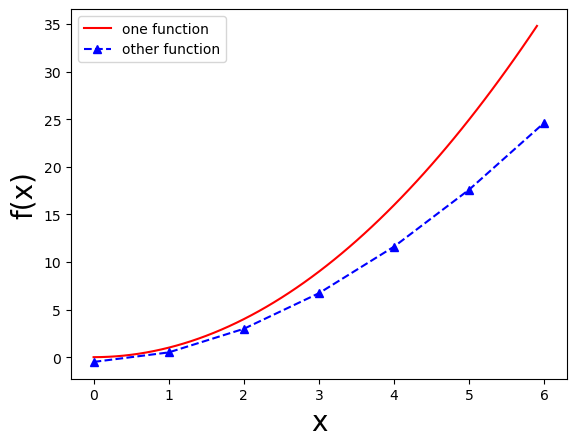

In [ ]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

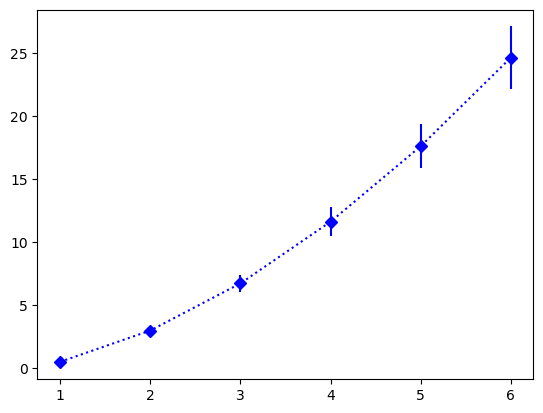

In [ ]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [ ]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [ ]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])